In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 12,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#333333",
    }
)

### 1. Inspect

In [2]:
# Define paths
csv_path = "../data/HAM10000_metadata.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display 5 first entries of the dataset
display(df.head())

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
print("--- DATASET SHAPE ---")
print(f"Total images (rows): {df.shape[0]}")
print(f"Total features (columns): {df.shape[1]}\n")

print("--- DATA TYPES & NON-NULL COUNTS ---")
df.info()

print("\n--- MISSING VALUES ---")
display(df.isnull().sum())

--- DATASET SHAPE ---
Total images (rows): 10015
Total features (columns): 7

--- DATA TYPES & NON-NULL COUNTS ---
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB

--- MISSING VALUES ---


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

### 2. Drop NaNs

In [4]:
print(f"Dataset size before dropping NaNs: {len(df)}")

# Drop rows where 'age' is missing
df = df.dropna(subset=["age"])

print(f"Dataset size after dropping NaNs: {len(df)}")
print(f"Missing values in 'age' now: {df['age'].isnull().sum()}")

Dataset size before dropping NaNs: 10015
Dataset size after dropping NaNs: 9958
Missing values in 'age' now: 0


### 3. Remove duplicates and 'unknown' values

In [5]:
# Investigate the relationship between images and actual lesions
lesion_counts = df["lesion_id"].value_counts()
print(f"Total unique lesions (patients): {len(lesion_counts)}")
print(f"Total images: {len(df)}")
multi_image_lesions = lesion_counts[lesion_counts > 1]
print(f"Lesions with multiple images: {len(multi_image_lesions)}\n")

# Keep only the first image for each lesion to ensure a clean dataset
df_clean = df.drop_duplicates(subset=["lesion_id"], keep="first")
print(f"Dataset size after removing duplicates: {len(df_clean)}")

# Investigate how many 'unknown' values in the 'sex' column
unknown_sex_count = df_clean[df_clean["sex"] == "unknown"].shape[0]
print(f"Number of 'unknown' values in 'sex' column: {unknown_sex_count}")
df_clean = df_clean[df_clean["sex"] != "unknown"]
print(f"Dataset size after removing 'unknown' sex entries: {len(df_clean)}")

# Investigate how many 'unknown' values in the 'localization' column
unknown_loc_count = df_clean[df_clean["localization"] == "unknown"].shape[0]
print(f"Number of 'unknown' values in 'localization' column: {unknown_loc_count}")
df_clean = df_clean[df_clean["localization"] != "unknown"]
print(f"Dataset size after removing 'unknown' localization entries: {len(df_clean)}")

Total unique lesions (patients): 7418
Total images: 9958
Lesions with multiple images: 1951

Dataset size after removing duplicates: 7418
Number of 'unknown' values in 'sex' column: 4
Dataset size after removing 'unknown' sex entries: 7414
Number of 'unknown' values in 'localization' column: 157
Dataset size after removing 'unknown' localization entries: 7257


### 4. Save the cleaned version

In [6]:
# Save the cleaned metadata for the model training
clean_csv_path = "../data/HAM10000_metadata_cleaned.csv"
df_clean.to_csv(clean_csv_path, index=False)

print(f"Cleaned metadata successfully saved to: {clean_csv_path}")
print(f"Final dataset size after cleaning: {len(df_clean)}")

Cleaned metadata successfully saved to: ../data/HAM10000_metadata_cleaned.csv
Final dataset size after cleaning: 7257


### 5. Visualization

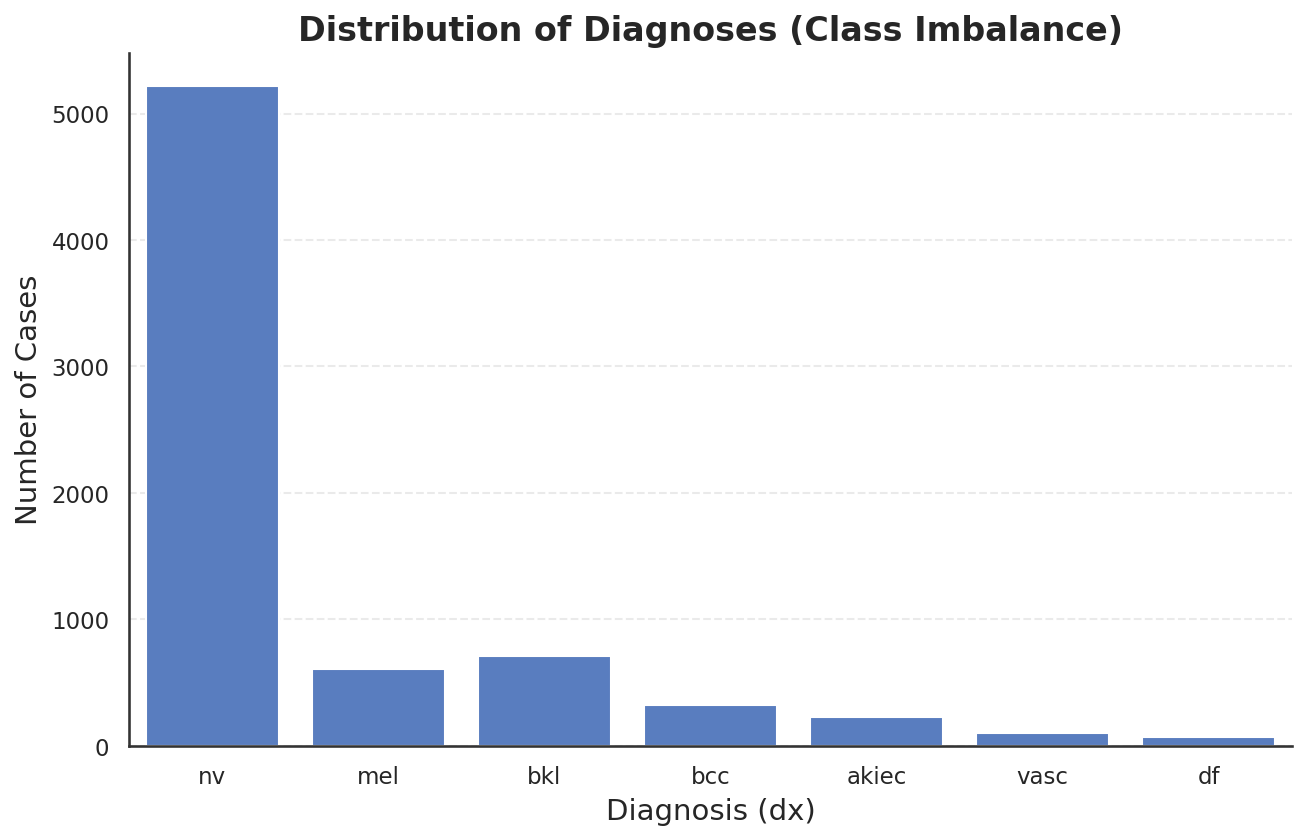

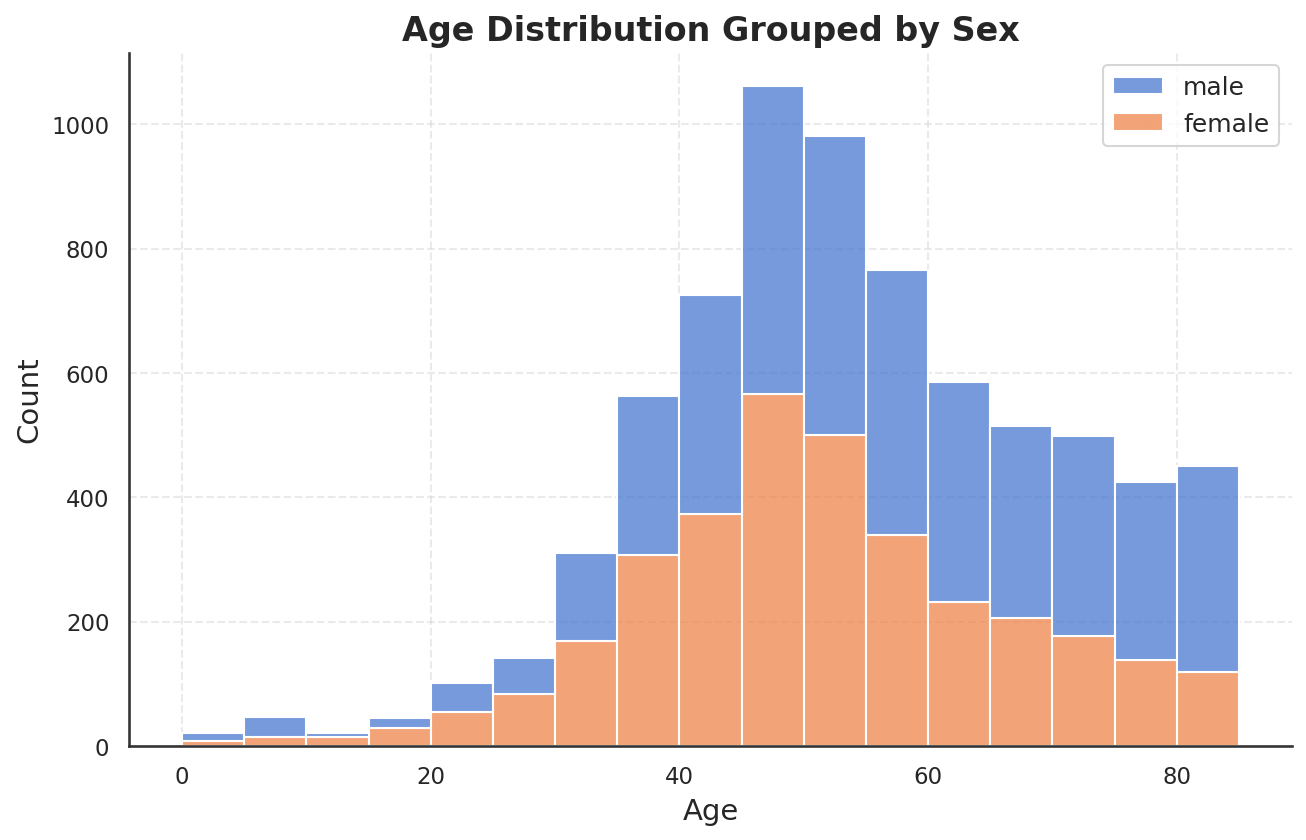

In [7]:
# Visualize Class Imbalance
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x="dx", order=df["dx"].value_counts().index)
plt.title("Distribution of Diagnoses (Class Imbalance)")
plt.ylabel("Number of Cases")
plt.xlabel("Diagnosis (dx)")
plt.show()

# Visualize Age Distribution by Sex
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_clean, x="age", hue="sex", multiple="stack", bins=17)
plt.title("Age Distribution Grouped by Sex")
plt.xlabel("Age")
plt.ylabel("Count")
legend = ax.get_legend()
if legend:
    legend.set_title("")
plt.show()

Sampling images for visualization...


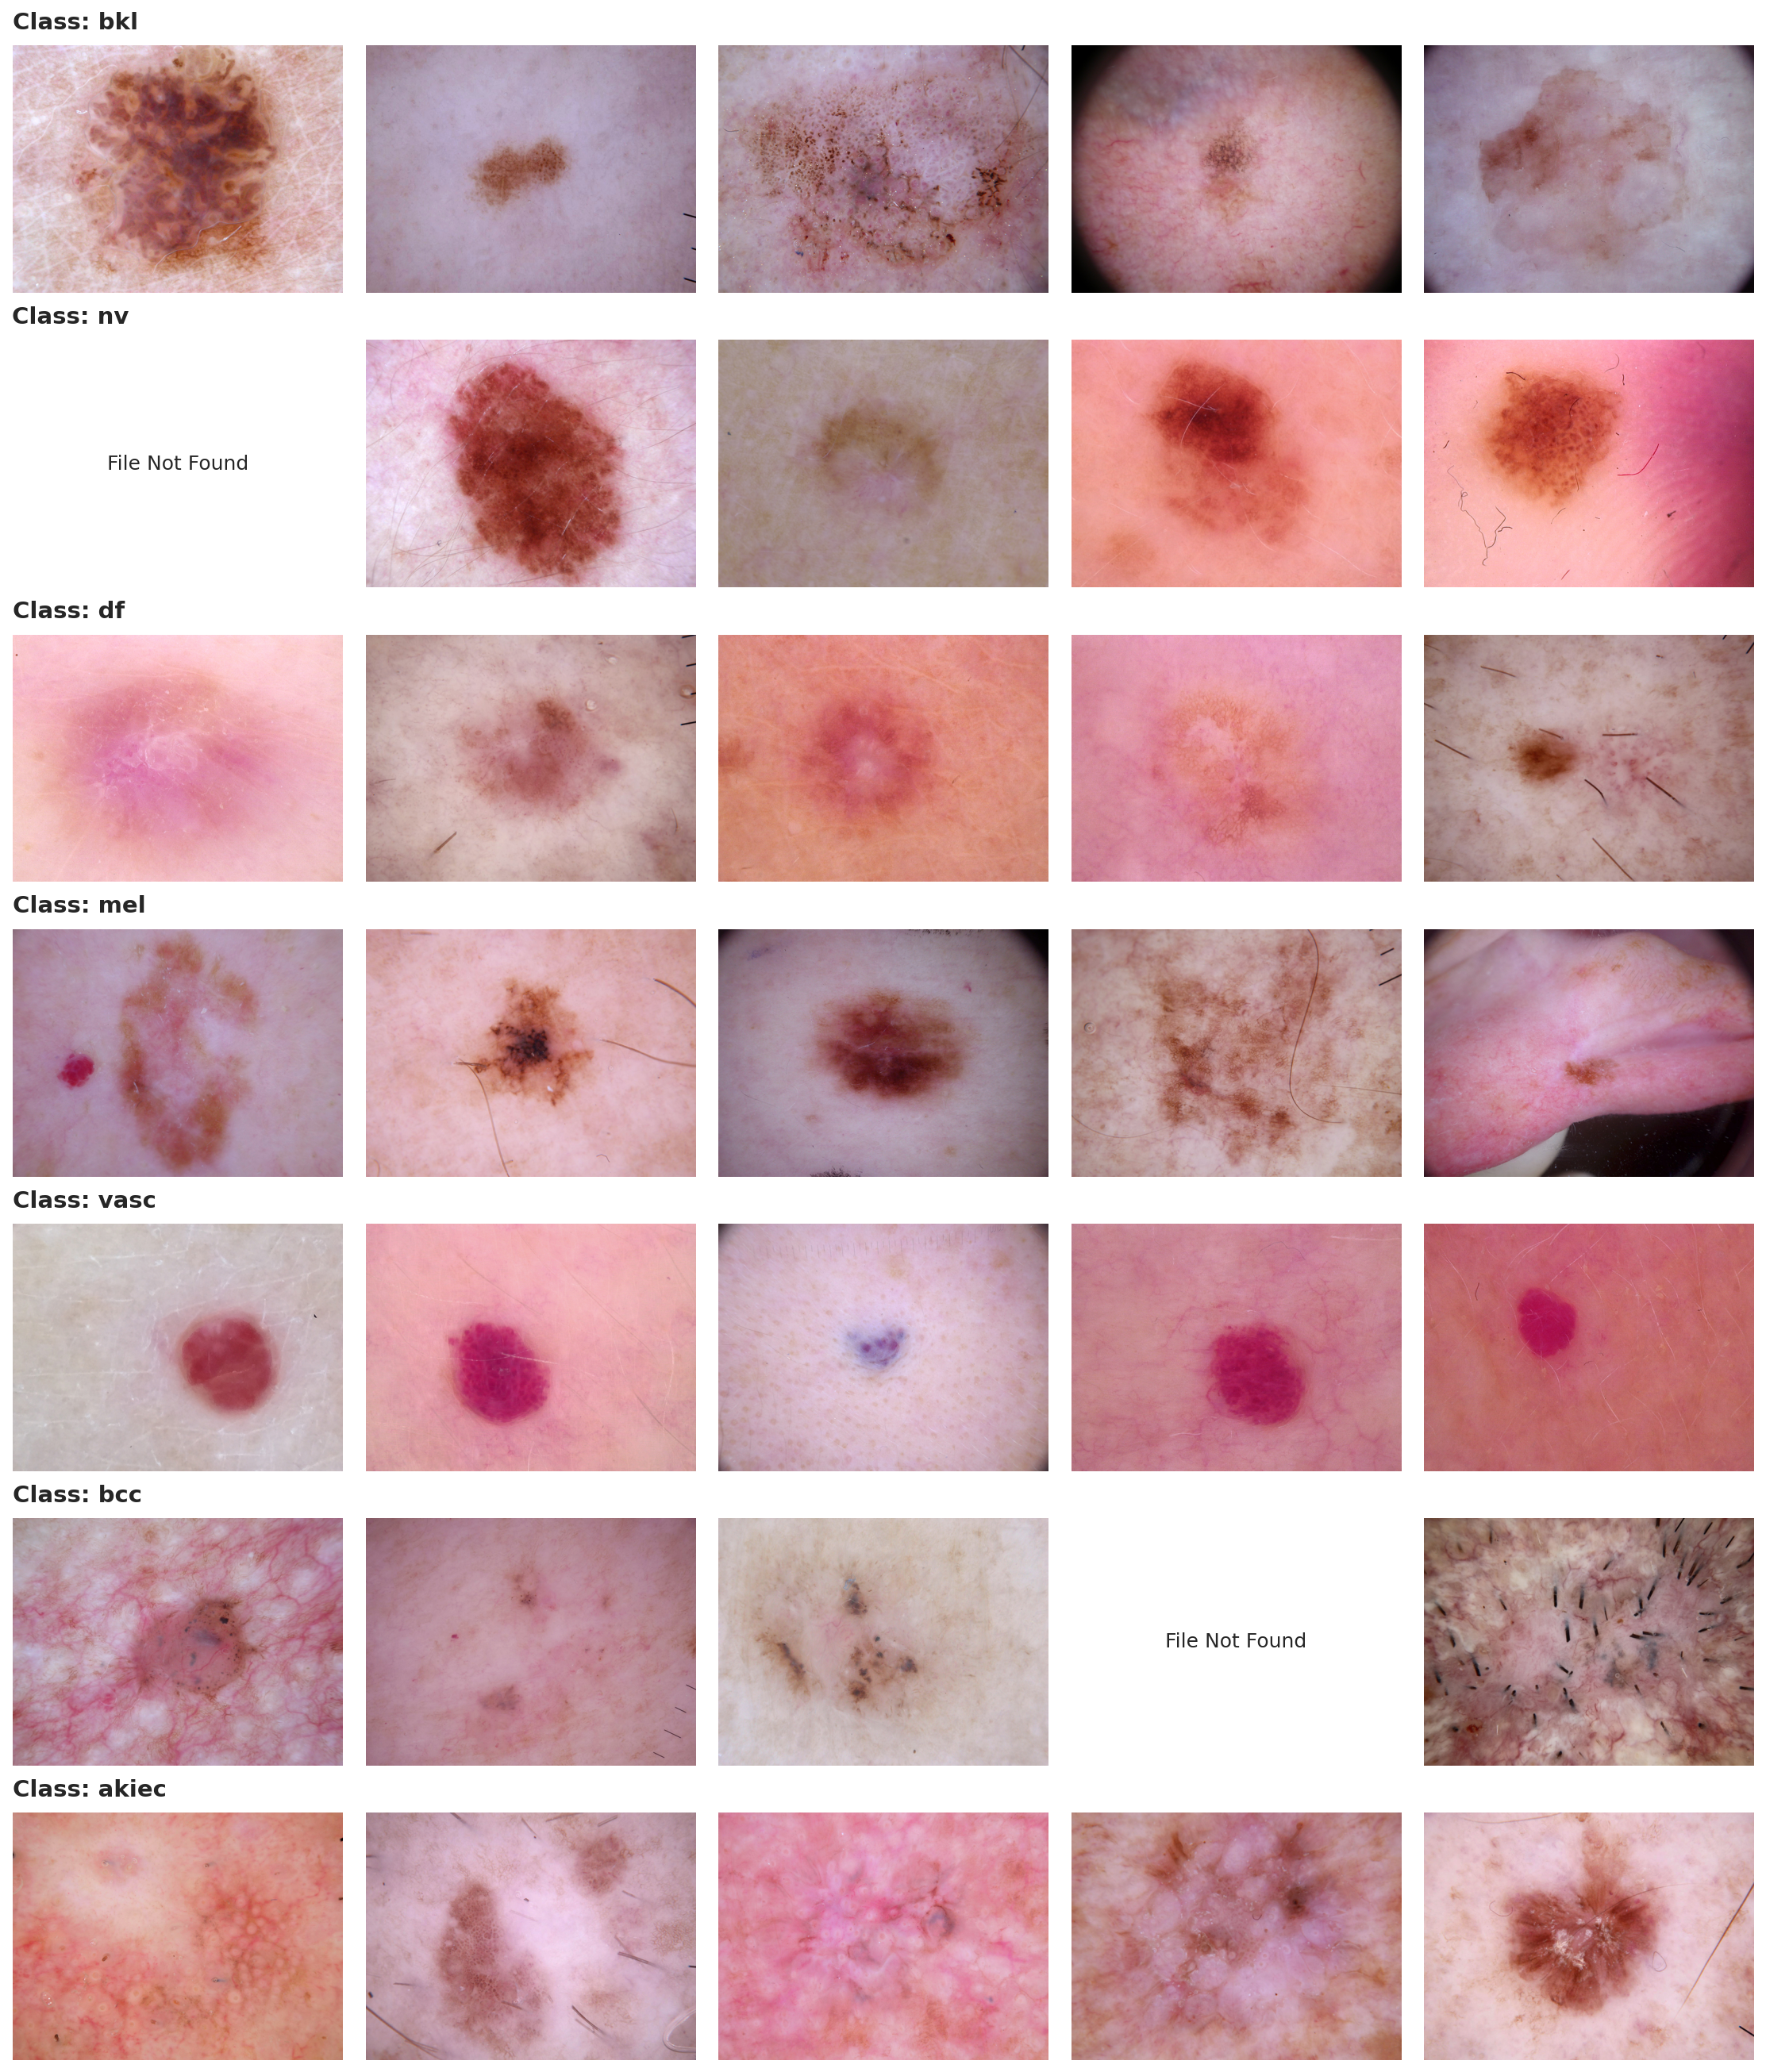

In [8]:
print("Sampling images for visualization...")

# Image directory
img_dir = "../data/HAM10000_images"

# Get all unique diagnoses
classes = df_clean["dx"].unique()

# Define grid size: 1 row per class, 5 images per row
n_cols = 5
n_rows = len(classes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.5 * n_rows))

for i, cls in enumerate(classes):
    # Sample 5 random records for the current class
    sample_df = df_clean[df_clean["dx"] == cls].sample(
        n=n_cols, replace=True, random_state=42
    )

    for j, (_, row) in enumerate(sample_df.iterrows()):
        img_id = row["image_id"]
        img_path = os.path.join(img_dir, f"{img_id}.jpg")

        # Load and display the image
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[i, j].imshow(img)
        else:
            axes[i, j].text(0.5, 0.5, "File Not Found", ha="center", va="center")

        axes[i, j].axis("off")

        # Add a title to the first image of each row to identify the class
        if j == 0:
            axes[i, j].set_title(
                f"Class: {cls}", fontsize=14, fontweight="bold", loc="left", pad=10
            )

plt.tight_layout()
plt.show()